In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import zipfile
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

2026-04-15 11:47:50.893863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776253671.303922      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776253671.421025      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776253672.456347      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776253672.456400      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776253672.456404      55 computation_placer.cc:177] computation placer alr

In [2]:
# Suppress annoying TensorFlow warning logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# ==========================================
# 1. DOWNLOAD & EXTRACT DATASET (Mendeley)
# ==========================================
dataset_url = "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded"
zip_path = "plant_dataset.zip"
extract_path = "./plant_dataset"

if not os.path.exists(zip_path):
    print("📥 Downloading dataset from Mendeley...")
    os.system(f"wget {dataset_url} -O {zip_path}")
else:
    print("✅ Dataset archive already exists.")

if not os.path.exists(extract_path):
    print("📂 Extracting files... (This may take a moment)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
else:
    print("✅ Dataset already extracted.")

def find_data_root(base):
    """Finds the actual folder containing the class subdirectories."""
    for root, dirs, files in os.walk(base):
        if len(dirs) > 30: 
            return root 
    return base

DATA_DIR = find_data_root(extract_path)
print(f"🎯 DATA_DIR is set to: {DATA_DIR}")

📥 Downloading dataset from Mendeley...


--2026-04-15 11:48:32--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/d29ed9b2-8a5d-4663-8a82-c9174f2c7066 [following]
--2026-04-15 11:48:33--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/d29ed9b2-8a5d-4663-8a82-c9174f2c7066
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.64.214, 3.5.69.35, 3.5.64.206, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.64.214|:443... conne

📂 Extracting files... (This may take a moment)
🎯 DATA_DIR is set to: ./plant_dataset/Plant_leave_diseases_dataset_without_augmentation


In [3]:
# ==========================================
# 2. DATA PREPROCESSING & GENERATORS
# ==========================================
print("⏳ Preparing Data Generators...")
train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixels to 0-1
    rotation_range=20,     # Augmentation: Rotate
    zoom_range=0.2,        # Augmentation: Zoom
    horizontal_flip=True,  # Augmentation: Flip
    validation_split=0.2   # 80% Train, 20% Validation
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Dynamically get the exact number of classes to prevent Shape errors
NUM_CLASSES = len(train_generator.class_indices)
print(f"🔍 Found {NUM_CLASSES} classes in the dataset.")

⏳ Preparing Data Generators...
Found 44371 images belonging to 39 classes.
Found 11077 images belonging to 39 classes.
🔍 Found 39 classes in the dataset.


In [5]:
# ==========================================
# 3. BUILD AI MODEL (MobileNetV2 Transfer Learning)
# ==========================================
print("🧠 Building the Neural Network...")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False # Freeze pre-trained base layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) # Prevent overfitting
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # Dynamic output layer

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy']
             )

🧠 Building the Neural Network...


/tmp/ipykernel_55/1042141735.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
I0000 00:00:1774435410.797579      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774435410.803641      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# ==========================================
# 4. CALLBACKS & TRAINING
# ==========================================
checkpoint = ModelCheckpoint("plant_cnn_model.h5", 
                             monitor='val_accuracy', 
                             save_best_only=True, 
                             verbose=1)

early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=3, 
                               restore_best_weights=True, 
                               verbose=1)

EPOCHS = 10
print(f"🚀 Starting training for {EPOCHS} epochs...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

print("✅ Training Complete!")

🚀 Starting training for 10 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1773669871.393942     140 service.cc:152] XLA service 0x7fcf001112d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773669871.393992     140 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773669871.393997     140 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773669872.405433     140 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-16 14:04:40.712766: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-16 14:04:40.847875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773669882.874566     140 device_co

 970/1387 ━━━━━━━━━━━━━━━━━━━━ 2:51 411ms/step - accuracy: 0.7142 - loss: 1.1357

...

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 699s 504ms/step - accuracy: 0.9371 - loss: 0.1967 - val_accuracy: 0.9454 - val_loss: 0.1688
Epoch 4/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9423 - loss: 0.1776
Epoch 4: val_accuracy improved from 0.94538 to 0.94791, saving model to plant_cnn_model.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 694s 500ms/step - accuracy: 0.9423 - loss: 0.1776 - val_accuracy: 0.9479 - val_loss: 0.1598
Epoch 5/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9450 - loss: 0.1627
Epoch 5: val_accuracy did not improve from 0.94791
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 695s 501ms/step - accuracy: 0.9450 - loss: 0.1627 - val_accuracy: 0.9460 - val_loss: 0.1609
Epoch 6/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9479 - loss: 0.1573
Epoch 6: val_accuracy improved from 0.94791 to 0.95297, saving model to plant_cnn_model.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 714s 515ms/step - accuracy: 0.9479 - loss: 0.1573 - val_accuracy: 0.9530 - val_loss: 0.1409
Epoch 7/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9502 - loss: 0.1491
Epoch 7: val_accuracy did not improve from 0.95297
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 712s 513ms/step - accuracy: 0.9502 - loss: 0.1491 - val_accuracy: 0.9504 - val_loss: 0.1477
Epoch 8/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9520 - loss: 0.1454
Epoch 8: val_accuracy improved from 0.95297 to 0.95441, saving model to plant_cnn_model.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 730s 527ms/step - accuracy: 0.9520 - loss: 0.1454 - val_accuracy: 0.9544 - val_loss: 0.1343
Epoch 9/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9537 - loss: 0.1422
Epoch 9: val_accuracy improved from 0.95441 to 0.95585, saving model to plant_cnn_model.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 711s 513ms/step - accuracy: 0.9537 - loss: 0.1422 - val_accuracy: 0.9559 - val_loss: 0.1311
Epoch 10/10
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9523 - loss: 0.1437
Epoch 10: val_accuracy did not improve from 0.95585
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 699s 504ms/step - accuracy: 0.9523 - loss: 0.1437 - val_accuracy: 0.9542 - val_loss: 0.1392
Restoring model weights from the end of the best epoch: 9.
✅ Training Complete!


In [7]:
# ==========================================
# 5. SAVE LABELS FOR FLASK APP
# ==========================================
class_indices = train_generator.class_indices
class_names_dict = {v: k for k, v in class_indices.items()}

with open("class_names.json", "w") as f:
    json.dump(class_names_dict, f, indent=4)
print("✅ Saved class_names.json successfully.")

✅ Saved class_names.json successfully.


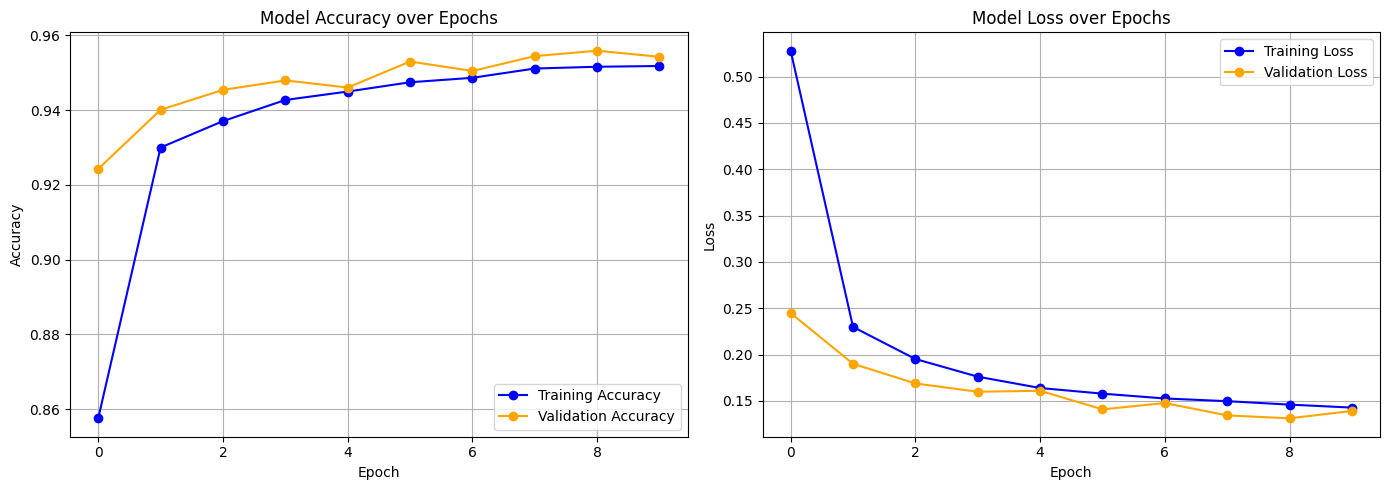

In [8]:
# ==========================================
# 6. PLOT RESULTS
# ==========================================
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

📊 1. Performing EDA on the COMPLETE dataset...


/tmp/ipykernel_55/4220348243.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=all_class_counts, y=all_class_names, palette='coolwarm')


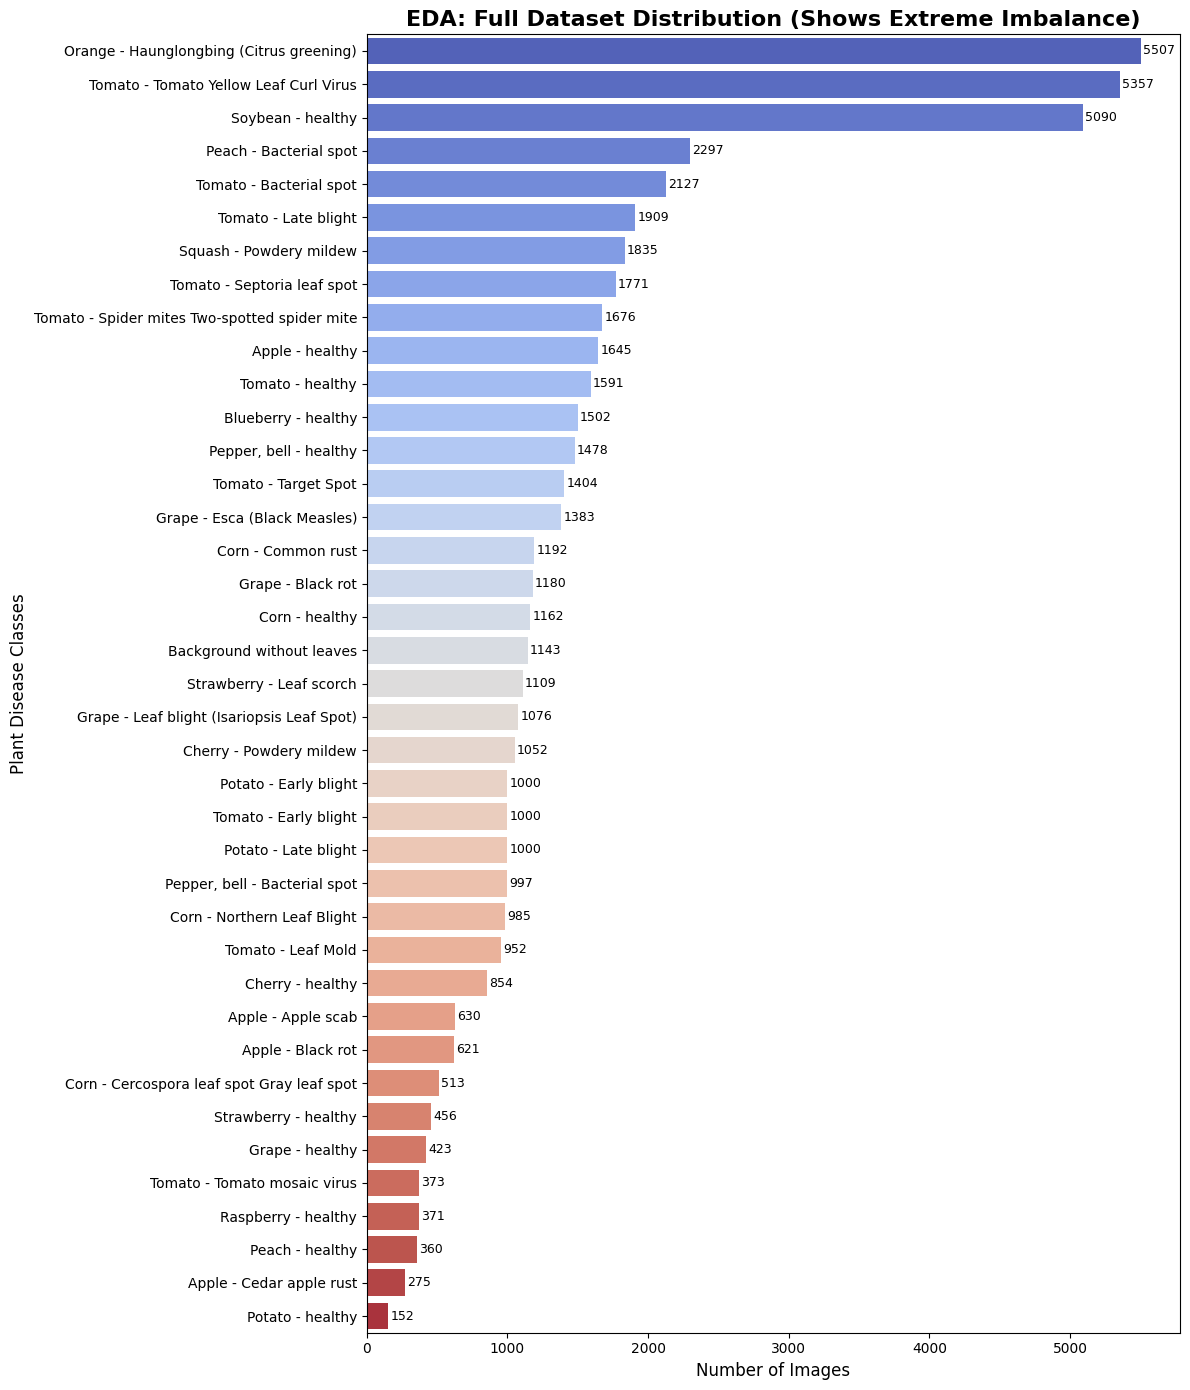

In [3]:
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to make ugly folder names readable for the teacher
def clean_name(name):
    return name.replace('___', ' - ').replace('_', ' ')

# ==========================================
# 1. FULL DATASET EDA (All 38 Classes)
# ==========================================
print("📊 1. Performing EDA on the COMPLETE dataset...")

class_counts = {}
for folder_name in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder_name)
    if os.path.isdir(folder_path):
        class_counts[folder_name] = len(os.listdir(folder_path))

sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
all_class_names = [clean_name(cls[0]) for cls in sorted_classes] # Cleaned names
all_class_counts = [cls[1] for cls in sorted_classes]

# --- PLOT 1: All 38 Classes (Horizontal & Clean) ---
plt.figure(figsize=(12, 14)) # Taller figure to fit all 38 names comfortably
ax = sns.barplot(x=all_class_counts, y=all_class_names, palette='coolwarm')
plt.title("EDA: Full Dataset Distribution (Shows Extreme Imbalance)", fontsize=16, fontweight='bold')
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Plant Disease Classes", fontsize=12)

# Add exact numbers to the end of each bar
for i, v in enumerate(all_class_counts):
    ax.text(v + 15, i, str(v), color='black', va='center', fontsize=9)
    
plt.tight_layout()
plt.show()


🏆 2. Selecting Top 10 Classes to fix the imbalance...


/tmp/ipykernel_55/352327360.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_counts, y=top_10_names_clean, palette='Blues_r')


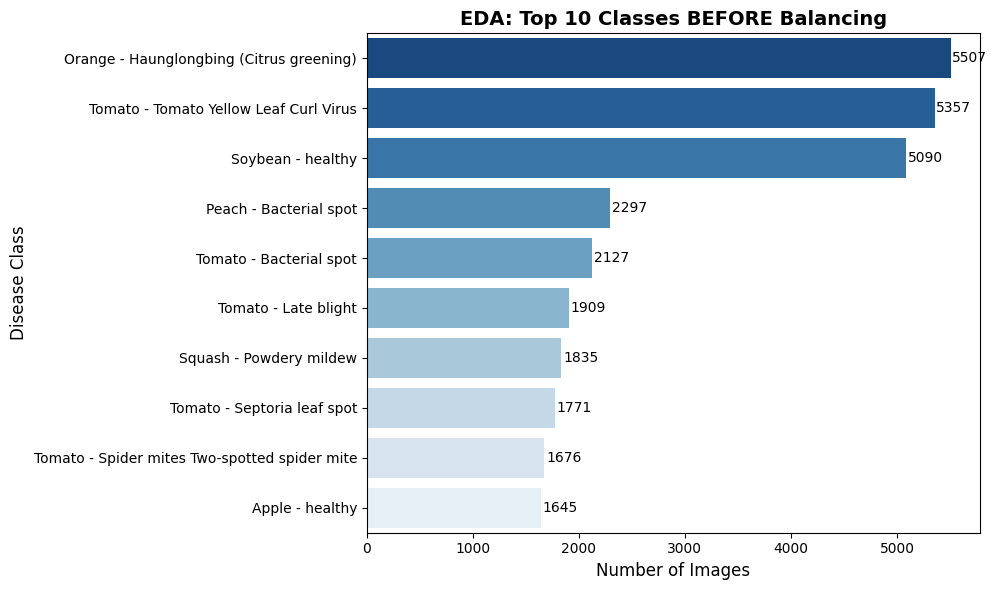


⚖️ 3. Balancing Data: Capping all Top 10 classes to exactly 1645 images.
✅ Perfectly balanced dataset created at: ./balanced_plant_dataset


/tmp/ipykernel_55/352327360.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=balanced_counts, y=top_10_names_clean, palette='Greens_r')


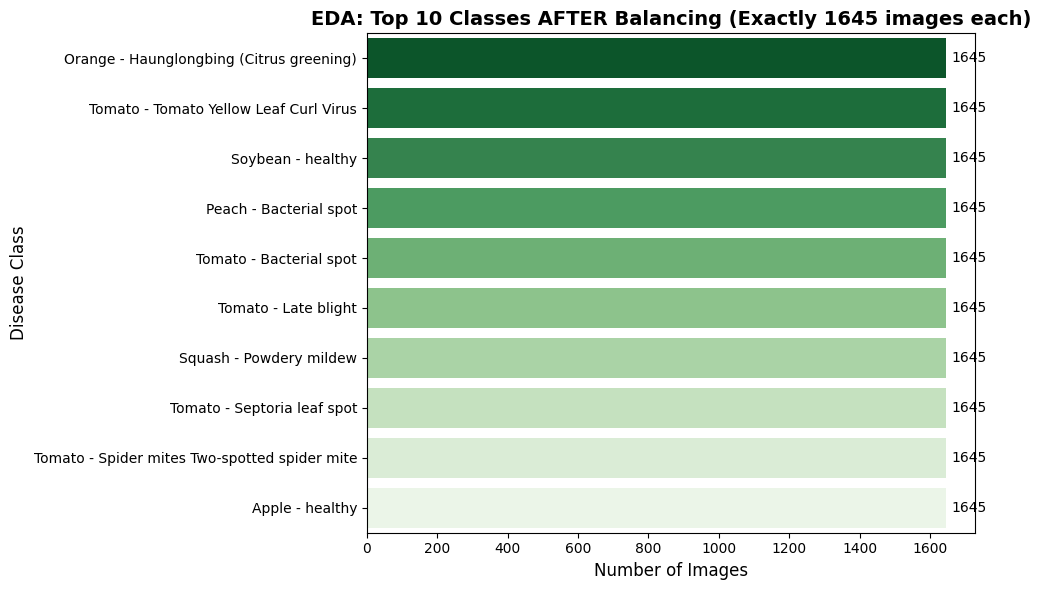

In [4]:
# ==========================================
# 2. SELECTING & BALANCING TOP 10 CLASSES
# ==========================================
print("\n🏆 2. Selecting Top 10 Classes to fix the imbalance...")
top_10 = sorted_classes[:10]
top_10_names_raw = [cls[0] for cls in top_10] # Keep raw names for moving folders
top_10_names_clean = [clean_name(cls[0]) for cls in top_10] # Clean names for plot
top_10_counts = [cls[1] for cls in top_10]

# --- PLOT 2: Top 10 BEFORE Balancing ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_10_counts, y=top_10_names_clean, palette='Blues_r')
plt.title("EDA: Top 10 Classes BEFORE Balancing", fontsize=14, fontweight='bold')
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Disease Class", fontsize=12)

# Add exact numbers
for i, v in enumerate(top_10_counts):
    ax.text(v + 15, i, str(v), color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# --- BALANCING LOGIC ---
LIMIT = top_10_counts[-1]
print(f"\n⚖️ 3. Balancing Data: Capping all Top 10 classes to exactly {LIMIT} images.")

BALANCED_DIR = "./balanced_plant_dataset"
if not os.path.exists(BALANCED_DIR):
    os.makedirs(BALANCED_DIR)

for class_name in top_10_names_raw:
    src_folder = os.path.join(DATA_DIR, class_name)
    dest_folder = os.path.join(BALANCED_DIR, class_name)
    
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
        
    images = os.listdir(src_folder)[:LIMIT] 
    for img in images:
        src_img_path = os.path.join(src_folder, img)
        dest_img_path = os.path.join(dest_folder, img)
        if not os.path.exists(dest_img_path):
            shutil.copy(src_img_path, dest_img_path)

print(f"✅ Perfectly balanced dataset created at: {BALANCED_DIR}")

# --- PLOT 3: Top 10 AFTER Balancing ---
balanced_counts = [LIMIT] * 10 

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=balanced_counts, y=top_10_names_clean, palette='Greens_r')
plt.title(f"EDA: Top 10 Classes AFTER Balancing (Exactly {LIMIT} images each)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Images", fontsize=12)
plt.ylabel("Disease Class", fontsize=12)

# Add exact numbers
for i, v in enumerate(balanced_counts):
    ax.text(v + 15, i, str(v), color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Overwrite DATA_DIR so the generator uses the balanced data
DATA_DIR = BALANCED_DIR

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==========================================
# 3. PREPROCESSING & AUGMENTATION
# ==========================================
print("⏳ Preparing Data Generators for the Balanced Top 10 Classes...")

# TEACHER NOTE: 
# 1. `rescale` is PREPROCESSING (Normalizing raw pixels to 0-1 range).
# 2. `rotation`, `zoom`, and `flip` are AUGMENTATION (Creating variations to prevent overfitting).
train_datagen = ImageDataGenerator(
    rescale=1./255,        # PREPROCESSING
    rotation_range=20,     # AUGMENTATION
    zoom_range=0.2,        # AUGMENTATION
    horizontal_flip=True,  # AUGMENTATION
    validation_split=0.2   # SPLIT DATA (80% Train, 20% Val)
)

# TEACHER NOTE: We use flow_from_directory to import images in batches to save RAM!
train_generator = train_datagen.flow_from_directory(
    DATA_DIR, # This now points to our balanced folder!
    target_size=(256, 256), # PREPROCESSING (Resizing)
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False # Keep false for validation so we can build a Confusion Matrix later
)

NUM_CLASSES = len(train_generator.class_indices)
print(f"✅ Ready to train on exactly {NUM_CLASSES} classes.")

⏳ Preparing Data Generators for the Balanced Top 10 Classes...
Found 13160 images belonging to 10 classes.
Found 3290 images belonging to 10 classes.
✅ Ready to train on exactly 10 classes.


In [6]:
import json
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from IPython.display import FileLink, display # Added for Kaggle downloads

# ==========================================
# 4. BUILD & TRAIN THE AI MODEL
# ==========================================
print("🧠 Building the MobileNetV2 Neural Network...")

# Base Model (Feature Extractor)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model.trainable = False # Freeze the 53 base layers

# Custom Head (Classifier)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) 
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # 10 Neurons for 10 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Callbacks (Smart Training)
checkpoint = ModelCheckpoint("plant_cnn_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

# Start Training
EPOCHS = 10
print(f"🚀 Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping]
)
print("✅ Training Complete!")

# Explicitly save the final model just in case you want the last epoch regardless of early stopping
model.save("plant_cnn_model_final.h5") 

# Save labels for Flask App
class_indices = train_generator.class_indices
class_names_dict = {v: k for k, v in class_indices.items()}
with open("class_names.json", "w") as f:
    json.dump(class_names_dict, f, indent=4)
print("📝 Class names saved!")

# ==========================================
# 5. GENERATE DOWNLOAD LINKS
# ==========================================
print("⬇️ Click the links below to download your files directly:")

# Best model saved by the ModelCheckpoint
display(FileLink("plant_cnn_model.h5"))

# The JSON dictionary of your classes
display(FileLink("class_names.json"))

🧠 Building the MobileNetV2 Neural Network...


/tmp/ipykernel_55/4085958444.py:14: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
I0000 00:00:1776253820.698133      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776253820.704107      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Starting training for 10 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


...

412/412 ━━━━━━━━━━━━━━━━━━━━ 208s 504ms/step - accuracy: 0.9643 - loss: 0.1096 - val_accuracy: 0.9696 - val_loss: 0.0966
Epoch 6/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.9678 - loss: 0.0964
Epoch 6: val_accuracy improved from 0.96960 to 0.97508, saving model to plant_cnn_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 208s 505ms/step - accuracy: 0.9678 - loss: 0.0964 - val_accuracy: 0.9751 - val_loss: 0.0793
Epoch 7/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9744 - loss: 0.0818
Epoch 7: val_accuracy did not improve from 0.97508
412/412 ━━━━━━━━━━━━━━━━━━━━ 203s 492ms/step - accuracy: 0.9744 - loss: 0.0818 - val_accuracy: 0.9708 - val_loss: 0.0809
Epoch 8/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9764 - loss: 0.0763
Epoch 8: val_accuracy did not improve from 0.97508
412/412 ━━━━━━━━━━━━━━━━━━━━ 201s 488ms/step - accuracy: 0.9764 - loss: 0.0763 - val_accuracy: 0.9717 - val_loss: 0.0899
Epoch 9/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9733 - loss: 0.0829
Epoch 9: val_accuracy did not improve from 0.97508
412/412 ━━━━━━━━━━━━━━━━━━━━ 203s 494ms/step - accuracy: 0.9733 - loss: 0.0829 - val_accuracy: 0.9705 - val_loss: 0.0783
Epoch 10/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9766 - loss: 0.0773
Epoch 10: 

✅ Training Complete!
📝 Class names saved!
⬇️ Click the links below to download your files directly:


/kaggle/working/plant_cnn_model.h5

/kaggle/working/class_names.json

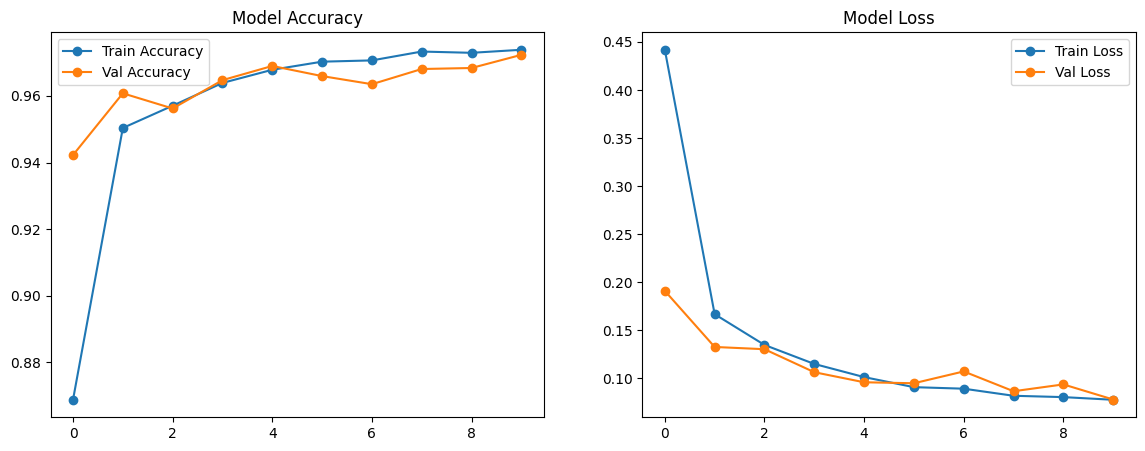


🔍 Generating Confusion Matrix to prove model reliability...
103/103 ━━━━━━━━━━━━━━━━━━━━ 54s 476ms/step


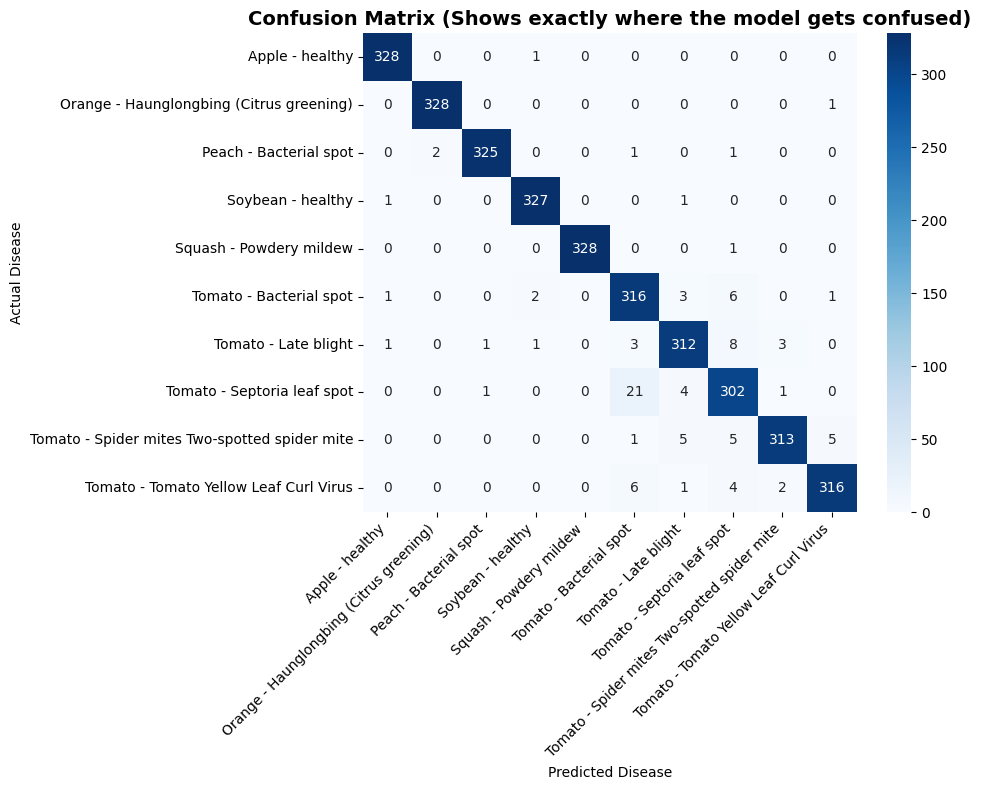


📄 Detailed Classification Report:
                                               precision    recall  f1-score   support

                              Apple - healthy       0.99      1.00      0.99       329
     Orange - Haunglongbing (Citrus greening)       0.99      1.00      1.00       329
                       Peach - Bacterial spot       0.99      0.99      0.99       329
                            Soybean - healthy       0.99      0.99      0.99       329
                      Squash - Powdery mildew       1.00      1.00      1.00       329
                      Tomato - Bacterial spot       0.91      0.96      0.93       329
                         Tomato - Late blight       0.96      0.95      0.95       329
                  Tomato - Septoria leaf spot       0.92      0.92      0.92       329
Tomato - Spider mites Two-spotted spider mite       0.98      0.95      0.97       329
       Tomato - Tomato Yellow Leaf Curl Virus       0.98      0.96      0.97       329

      

In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 5. MODEL EVALUATION & CONFUSION MATRIX
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.legend()
plt.show()

# --- CONFUSION MATRIX ---
print("\n🔍 Generating Confusion Matrix to prove model reliability...")

# Get actual labels and model predictions
val_generator.reset() # Reset generator before predicting
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

# Clean the class names for the chart
class_names = [clean_name(name) for name in list(train_generator.class_indices.keys())]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Shows exactly where the model gets confused)", fontsize=14, fontweight='bold')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print Final Report
print("\n📄 Detailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [14]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("🧠 Model 2: Building and Training ResNet50...")

# 1. Base Model
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
base_model_resnet.trainable = False 

# 2. Add custom head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions_resnet = Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet = Model(inputs=base_model_resnet.input, outputs=predictions_resnet)

model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Callbacks (Redefining them here to avoid NameErrors)
checkpoint_resnet = ModelCheckpoint("resnet50_plant_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True, 
    verbose=1
)

# 4. Train
history_resnet = model_resnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10, 
    callbacks=[checkpoint_resnet, early_stopping]
)
print("✅ ResNet50 Training Complete!")

🧠 Model 2: Building and Training ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.1300 - loss: 2.3612
Epoch 1: val_accuracy improved from -inf to 0.13556, saving model to resnet50_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 243s 558ms/step - accuracy: 0.1301 - loss: 2.3610 - val_accuracy: 0.1356 - val_loss: 2.1392
Epoch 2/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.2345 - loss: 2.1143
Epoch 2: val_accuracy improved from 0.13556 to 0.37812, saving model to resnet50_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 216s 524ms/step - accuracy: 0.2345 - loss: 2.1142 - val_accuracy: 0.3781 - val_loss: 1.9914
Epoch 3/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.2975 - loss: 2.0061
Epoch 3: val_accuracy did not improve from 0.37812
412/412 ━━━━━━━━━━━━━━━━━━━━ 215s 521ms/step - accuracy: 0.2976 - loss: 2.0060 - val_accuracy: 0.3289 - val_loss: 1.9246
Epoch 4/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3387 - loss: 1.9342
Epoch 4: val_accuracy did not improve from 0.37812
412/412 ━━━━━━━━━━━━━━━━━━━━ 213s 518ms/step - accuracy: 0.3387 - loss: 1.9342 - val_accuracy: 0.3626 - val_loss: 1.8841
Epoch 5/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.3542 - loss: 1.8889
Epoch 5: val_accuracy improved from 0.37812 to 0.38663, saving model to resnet50_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 214s 519ms/step - accuracy: 0.3543 - loss: 1.8888 - val_accuracy: 0.3866 - val_loss: 1.8444
Epoch 6/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.3694 - loss: 1.8338
Epoch 6: val_accuracy improved from 0.38663 to 0.44620, saving model to resnet50_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 214s 520ms/step - accuracy: 0.3695 - loss: 1.8338 - val_accuracy: 0.4462 - val_loss: 1.7776
Epoch 7/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.3876 - loss: 1.8055
Epoch 7: val_accuracy improved from 0.44620 to 0.47508, saving model to resnet50_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 212s 515ms/step - accuracy: 0.3876 - loss: 1.8055 - val_accuracy: 0.4751 - val_loss: 1.7512
Epoch 8/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.4055 - loss: 1.7654
Epoch 8: val_accuracy did not improve from 0.47508
412/412 ━━━━━━━━━━━━━━━━━━━━ 213s 518ms/step - accuracy: 0.4055 - loss: 1.7653 - val_accuracy: 0.4726 - val_loss: 1.7129
Epoch 9/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.4253 - loss: 1.7334
Epoch 9: val_accuracy did not improve from 0.47508
412/412 ━━━━━━━━━━━━━━━━━━━━ 213s 517ms/step - accuracy: 0.4253 - loss: 1.7335 - val_accuracy: 0.4635 - val_loss: 1.6885
Epoch 10/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.4194 - loss: 1.7118
Epoch 10: val_accuracy improved from 0.47508 to 0.48237, saving model to resnet50_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 212s 514ms/step - accuracy: 0.4194 - loss: 1.7118 - val_accuracy: 0.4824 - val_loss: 1.6491
Restoring model weights from the end of the best epoch: 10.
✅ ResNet50 Training Complete!


In [15]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

print("🧠 Model 3: Building and Training InceptionV3...")

# Note: Using InceptionV3's specific preprocessing usually helps accuracy
train_datagen_inception = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Special preprocessing for Inception
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# New generators specifically for Inception
train_gen_inc = train_datagen_inception.flow_from_directory(
    DATA_DIR, # Points to your balanced dataset
    target_size=(299, 299), # InceptionV3 prefers 299x299
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen_inc = train_datagen_inception.flow_from_directory(
    DATA_DIR,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 1. Base Model
base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model_inception.trainable = False 

# 2. Custom Head
x = base_model_inception.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions_inc = Dense(NUM_CLASSES, activation='softmax')(x)

model_inc = Model(inputs=base_model_inception.input, outputs=predictions_inc)
model_inc.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Callbacks
checkpoint_inc = ModelCheckpoint("inception_plant_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)

# 4. Train
history_inc = model_inc.fit(
    train_gen_inc,
    validation_data=val_gen_inc,
    epochs=10,
    callbacks=[checkpoint_inc, early_stopping]
)
print("✅ InceptionV3 Training Complete!")

🧠 Model 3: Building and Training InceptionV3...
Found 13160 images belonging to 10 classes.
Found 3290 images belonging to 10 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.6838 - loss: 1.0282
Epoch 1: val_accuracy improved from -inf to 0.92097, saving model to inception_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 346s 795ms/step - accuracy: 0.6842 - loss: 1.0272 - val_accuracy: 0.9210 - val_loss: 0.2994
Epoch 2/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9234 - loss: 0.2685
Epoch 2: val_accuracy improved from 0.92097 to 0.94255, saving model to inception_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 303s 734ms/step - accuracy: 0.9234 - loss: 0.2684 - val_accuracy: 0.9426 - val_loss: 0.1901
Epoch 3/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9422 - loss: 0.1931
Epoch 3: val_accuracy improved from 0.94255 to 0.94438, saving model to inception_plant_model.h5


...

412/412 ━━━━━━━━━━━━━━━━━━━━ 306s 743ms/step - accuracy: 0.9490 - loss: 0.1722 - val_accuracy: 0.9495 - val_loss: 0.1527
Epoch 5/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.9499 - loss: 0.1513
Epoch 5: val_accuracy improved from 0.94954 to 0.95897, saving model to inception_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 306s 742ms/step - accuracy: 0.9499 - loss: 0.1513 - val_accuracy: 0.9590 - val_loss: 0.1289
Epoch 6/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9555 - loss: 0.1361
Epoch 6: val_accuracy did not improve from 0.95897
412/412 ━━━━━━━━━━━━━━━━━━━━ 303s 734ms/step - accuracy: 0.9555 - loss: 0.1361 - val_accuracy: 0.9532 - val_loss: 0.1433
Epoch 7/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.9565 - loss: 0.1323
Epoch 7: val_accuracy did not improve from 0.95897
412/412 ━━━━━━━━━━━━━━━━━━━━ 304s 738ms/step - accuracy: 0.9565 - loss: 0.1323 - val_accuracy: 0.9553 - val_loss: 0.1224
Epoch 8/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9555 - loss: 0.1313
Epoch 8: val_accuracy improved from 0.95897 to 0.96413, saving model to inception_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 306s 743ms/step - accuracy: 0.9555 - loss: 0.1313 - val_accuracy: 0.9641 - val_loss: 0.1052
Epoch 9/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.9590 - loss: 0.1165
Epoch 9: val_accuracy improved from 0.96413 to 0.96474, saving model to inception_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 313s 761ms/step - accuracy: 0.9590 - loss: 0.1165 - val_accuracy: 0.9647 - val_loss: 0.1007
Epoch 10/10
412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9610 - loss: 0.1169
Epoch 10: val_accuracy improved from 0.96474 to 0.96687, saving model to inception_plant_model.h5


412/412 ━━━━━━━━━━━━━━━━━━━━ 310s 753ms/step - accuracy: 0.9610 - loss: 0.1169 - val_accuracy: 0.9669 - val_loss: 0.1021
Restoring model weights from the end of the best epoch: 9.
✅ InceptionV3 Training Complete!


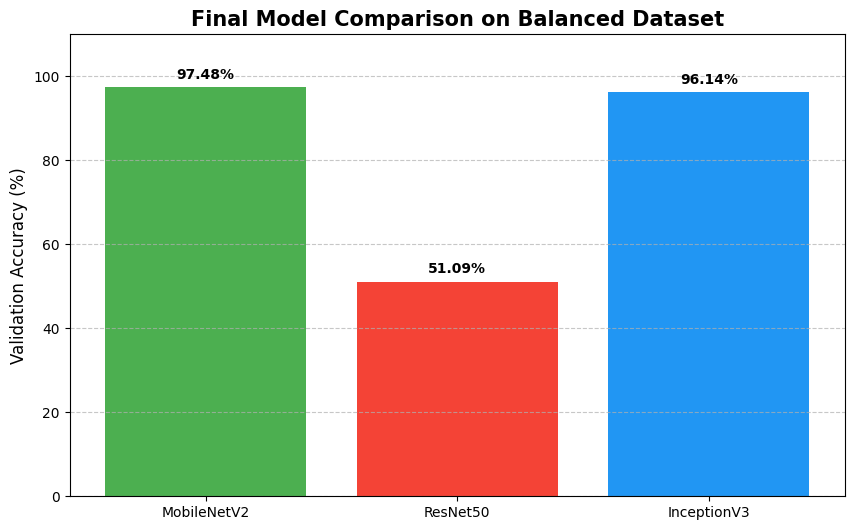


📋 FINAL RESEARCH SUMMARY:
1. Best Model: MobileNetV2 (97.48%)
2. Most Stable: InceptionV3 (96.14%)
3. Note: MobileNetV2 is selected for the final app due to its high accuracy and light weight.


In [16]:
import matplotlib.pyplot as plt

# Data from your training logs
models = ['MobileNetV2', 'ResNet50', 'InceptionV3']
accuracies = [97.48, 51.09, 96.14] # Final best val_accuracies

plt.figure(figsize=(10, 6))
colors = ['#4CAF50', '#F44336', '#2196F3'] # Green, Red, Blue

bars = plt.bar(models, accuracies, color=colors)
plt.ylim(0, 110)
plt.title('Final Model Comparison on Balanced Dataset', fontsize=15, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=12)

# Add exact numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\n📋 FINAL RESEARCH SUMMARY:")
print(f"1. Best Model: MobileNetV2 ({accuracies[0]}%)")
print(f"2. Most Stable: InceptionV3 ({accuracies[2]}%)")
print(f"3. Note: MobileNetV2 is selected for the final app due to its high accuracy and light weight.")

In [17]:
from sklearn.metrics import classification_report
import numpy as np

# Use your best model (MobileNetV2) to predict the validation set
val_generator.reset()
y_pred = np.argmax(model.predict(val_generator), axis=1)
y_true = val_generator.classes

# Generate the report
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))

103/103 ━━━━━━━━━━━━━━━━━━━━ 42s 407ms/step
                                               precision    recall  f1-score   support

                              Apple___healthy       0.99      1.00      0.99       329
     Orange___Haunglongbing_(Citrus_greening)       1.00      0.99      1.00       329
                       Peach___Bacterial_spot       1.00      0.98      0.99       329
                            Soybean___healthy       0.99      0.99      0.99       329
                      Squash___Powdery_mildew       1.00      1.00      1.00       329
                      Tomato___Bacterial_spot       0.92      0.96      0.94       329
                         Tomato___Late_blight       0.96      0.96      0.96       329
                  Tomato___Septoria_leaf_spot       0.92      0.91      0.92       329
Tomato___Spider_mites Two-spotted_spider_mite       0.98      0.96      0.97       329
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      0.96      0.97       32